# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU3.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.

## Část 1: Číselná spirála

Vytvořte čtvercovou matici o lichém počtu řádků a sloupců, která bude obsahovat čísla od 1 do $n^2$ tak, aby číslo 1 bylo uprostřed matice a číselná řada postupně narůstala po spirále proti směru hodinových ručiček.
- udělejte to pomocí NumPy přiřazování sliců do pole,
- výstup musí být stejný jako u primitivní funkce `integer_spiral` níže,
- vyplňujte matici po „kruzích“ okolo středu,
    - každý kruh je tvořen 4 částmi (hrana bez jednoho rohu),
    - využijte možnosti přiřazování sliců do pole a indexace s krokem `-1`,
    - použijte `np.arange` pro vytvoření řady čísel, kterou budete ukládat do hrany,
- pomozte si také okrajem z nul, který nakonec oříznete.

**Výsledná funkce bude mít tedy pouze jednu smyčku, ve které do pole vstoupíte pouze 4x (jednou za každou hranu).**

**Na závěr porovnejte rychlost vaší funkce s `integer_spiral` níže pomocí `%timeit` a různých velikostí výsledných matic (např. 101, 1001, 10001).**


In [48]:
import numpy as np
import matplotlib.pyplot as plt

In [49]:
# naplnění matice spirálou čísel
def integer_spiral(n):
    # abychom nemuseli řešit okraj = kontrolovat jestli jsme mimo matici
    # vytvoříme matici o velikosti n+2 x n+2
    # a vyplníme pouze středovou část
    A = np.zeros((n + 2, n + 2))

    pos_row = n//2 + 1  # počáteční pozice: střed matice
    pos_col = n//2 + 1

    i = 1  # číslo, které se bude vkládat do matice

    A[pos_row, pos_col] = i  # vložíme číslo do středu matice
    i += 1
    pos_col += 1  # posuneme se na první volné místo

    while i <= n**2:  # dokud nejsme na konci matice
        A[pos_row, pos_col] = i  # vložíme číslo na aktuální pozici
        i += 1  # zvýšíme číslo, které se má vložit
        if A[pos_row - 1, pos_col] != 0 and A[pos_row, pos_col + 1] == 0:
            pos_col += 1  # posuneme se doprava
        elif A[pos_row, pos_col - 1] != 0:
            pos_row -= 1  # posuneme se nahoru
        elif A[pos_row + 1, pos_col] != 0:
            pos_col -= 1  # posuneme se doleva
        else:
            pos_row += 1  # posuneme se dolů

    return A[1:-1, 1:-1]  # ořízneme nulový okraj


In [50]:
A = integer_spiral(7)
print(A)

[[37. 36. 35. 34. 33. 32. 31.]
 [38. 17. 16. 15. 14. 13. 30.]
 [39. 18.  5.  4.  3. 12. 29.]
 [40. 19.  6.  1.  2. 11. 28.]
 [41. 20.  7.  8.  9. 10. 27.]
 [42. 21. 22. 23. 24. 25. 26.]
 [43. 44. 45. 46. 47. 48. 49.]]


In [51]:
def integer_spiral_numpy(n):
    A = np.zeros((n + 2, n + 2))
    center = n//2 + 1

    i = 1
    A[center,center] = i
    i+=1

    for j in range(1, n//2 + 1):
        nums = np.arange(i, i + 2*j)
        A[center - j:center + j, center + j] = nums[::-1]
        i += 2*j

        nums = np.arange(i, i + 2*j)
        A[center - j,center - j:center +j] = nums[::-1]
        i += 2*j

        nums = np.arange(i, i + 2*j)
        A[center - j + 1:center + j + 1, center - j] = nums
        i += 2*j

        nums = np.arange(i, i + 2*j)
        A[center + j,center - j + 1:center + j + 1] = nums
        i += 2*j

    return A[1:-1, 1:-1]

In [52]:
B = integer_spiral_numpy(7)
print(B)

[[37. 36. 35. 34. 33. 32. 31.]
 [38. 17. 16. 15. 14. 13. 30.]
 [39. 18.  5.  4.  3. 12. 29.]
 [40. 19.  6.  1.  2. 11. 28.]
 [41. 20.  7.  8.  9. 10. 27.]
 [42. 21. 22. 23. 24. 25. 26.]
 [43. 44. 45. 46. 47. 48. 49.]]


In [60]:
print("čas pro matice velikosti 101 \nIntegral_spiral:")
%timeit A = integer_spiral(101)
print("Integral_spiral_numpy:")
%timeit B = integer_spiral_numpy(101)

print("čas pro matice 1001\nIntegral_spiral:")
%timeit A = integer_spiral(1001)
print("Integral_spiral_numpy:")
%timeit B = integer_spiral_numpy(1001)

print("čas pro matice 10001\nIntegral_spiral:")
%timeit A = integer_spiral(10001)
print("Integral_spiral_numpy:")
%timeit B = integer_spiral_numpy(10001)


čas pro matice velikosti 101 
Integral_spiral:
10.1 ms ± 226 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
Integral_spiral_numpy:
333 μs ± 8.26 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
čas pro matice 1001
:Integral_spiral:
1.02 s ± 25 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
Integral_spiral_numpy:
6.16 ms ± 237 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
čas pro matice 10001
Integral_spiral:
1min 45s ± 1.21 s per loop (mean ± std. dev. of 7 runs, 1 loop each)
Integral_spiral_numpy:
868 ms ± 24.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Část 2: Mandelbrotova množina
Vizualizujte Mandelbrotovu množinu na intervalu $[-2, 1] \times [-1.5, 1.5]$ pomocí `imshow`. Výsledek by měl vypadat jako na následujícím obrázku.
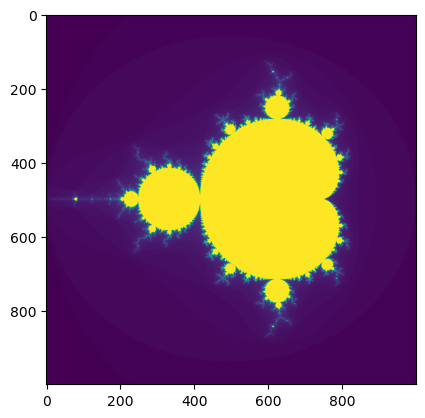

**Co je Mandelbrotova množina?**

Mandelbrotova množina je množina komplexních čísel $c$, pro které platí, že posloupnost $z_{i+1} = z_i^2 + c$ s $z_0 = 0$ nekonverguje do nekonečna (tj. $|z_i|$ zůstává omezené).

**Co tedy udělat?**
- vytvořte matici $n\times n$ komplexních čísel $c$ na intervalu $[-2, 1] \times [-1.5, 1.5]$ (pomocí `np.mgrid` nebo `np.meshgrid`),
    - využijte výhody vektorizace a toho, že NumPy umí násobit komplexní čísla,
- stanovte si počet iterací $k$, pro které budete testovat, zda posloupnost nedivergovala,
    - divergování posloupnosti poznáme tak, že $|z_i| > 2$ pro nějaké $i$,
- proveďte $k$ iterací posloupnosti $z_{i+1} = z_i^2 + c$ a zjistěte, ve které iteraci nastalo $|z_i| > 2$ (jakmile to nastane jednou, bude to platit pro všechna další $i$),
    - použijte pomocnou matici `divergence_matrix`, která bude mít stejný rozměr jako `c` a bude obsahovat počet iterací, kdy $|z_i| < 2$ pro každé $c$,
- vytvořte obrázek pomocí `imshow` z `divergence_matrix`.

In [88]:
def mandelbrot_set(x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5, n = 1000, k = 100):
    x = np.linspace(-2, 1, n)
    y = np.linspace(-1.5, 1.5, n)
    X, Y = np.meshgrid(x, y)
    c = X + 1j * Y
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            z = 0
            for l in range(k):
                z = z**2 + c[i,j]
                if abs(z) > 2:
                    break
            matrix[i,j] = l
                
    return matrix

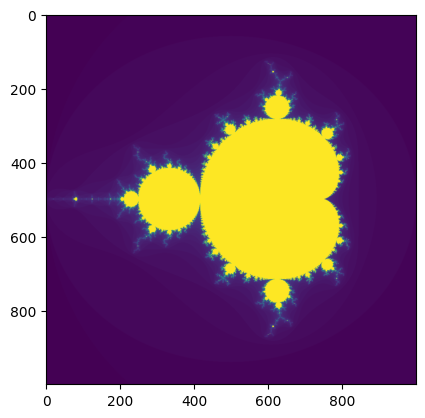

In [89]:
n = 1000
k = 100

divergence_matrix = mandelbrot_set(n=n, k=k)
plt.imshow(divergence_matrix)

## Bonusové úkoly
1. Vykreslete také Juliovu množinu (viz https://en.wikipedia.org/wiki/Julia_set).
2. Použijte váš kód pro číselnou spirálu a vytvořte obrázek prvočíselné spirály (viz https://en.wikipedia.org/wiki/Ulam_spiral).

In [92]:
def julia_set(c = -0.5125 + 0.5213j,x_min = -2, x_max = 1, y_min = -1.5, y_max = 1.5, n = 1000, k = 100):
    x = np.linspace(-2, 1, n)
    y = np.linspace(-1.5, 1.5, n)
    X, Y = np.meshgrid(x, y)
    matrix = np.zeros((n, n))

    for i in range(n):
        for j in range(n):
            z = X[i,j] + 1j * Y[i,j]
            for l in range(k):
                z = z**2 + c
                if abs(z) > 2:
                    break
            matrix[i,j] = l
                
    return matrix

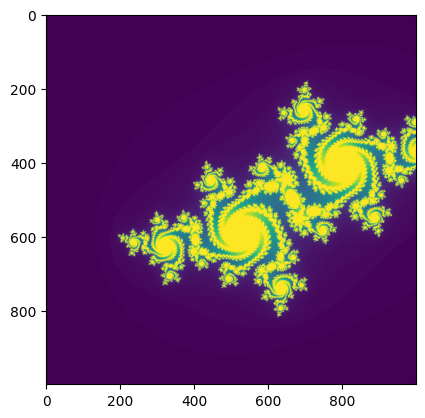

In [93]:
n = 1000
k = 100

divergence_matrix_julia = julia_set(n=n, k=k)
plt.imshow(divergence_matrix_julia)